# 1. Deutsch's algorithm

## 1a) Implement the algorithm by modifying the following cells

Below you will find the definition of the quantum querz gate $U_f$ for a secret function $f:\{0,1\}^n\rightarrow\{0,1\}$. Using Deutsch's algorithm, check whether secret_function is *constant* or *balanced* with query-complexity 1.

In [78]:
pip install qiskit

In [79]:
pip install qiskit_aer

In [80]:
#pip install pylatexenc

In [81]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import pylatexenc

In [82]:
def secret_function():
    f = QuantumCircuit(2)
    f.cx(0, 1)
    return f

We can check what the circuit looks like using the `draw` method.

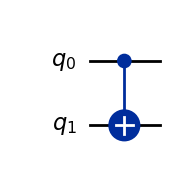

In [83]:
display(secret_function().draw(output='mpl'))

Now, you will create the actual quantum circuit for Deutsch's algorithm, using the query gate defined above.

Barriers are included to show the visual separation between the query gate implementation and the rest of the circuit.

In [115]:
def your_circuit(function: QuantumCircuit):
    # Compiles a circuit for use in Deutsch's algorithm.

    # this initializes a circuit with n+1 qubits and n classical bits
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    # remember that in Qiskit, all qubits start in the |0⟩ state
    #qc.x(1)

    # anything that happens before the query gate goes here

    qc.barrier()
    # The CNOT
    qc.compose(function, inplace=True)
    qc.barrier()

    # anything that happens after the query gate goes here

    # this examplary measurement measures the second qubit into the classical bit
    qc.measure(1, 0)

    return qc

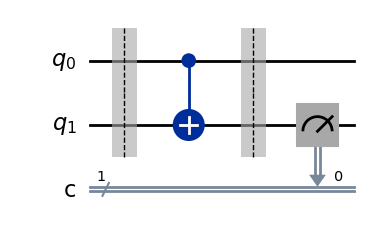

In [116]:
# check that your circuit is constructed correctly
display(your_circuit(secret_function()).draw(output='mpl'))

In [122]:
def deutsch_algorithm(function: QuantumCircuit):
    # Determine if a one-bit function is constant or balanced
    qc = your_circuit(function)

    # the following two lines extract the measurement result
    result = AerSimulator().run(qc, shots=1, memory=True).result()
    #  AerSimulator() is a local simulateur quantique, like a real computer here.
    measurements = result.get_memory()
    print(measurements)
    #  measurements ='0' means the function is constant (constructive interference)
    if measurements[0] == '0':
        return "constant"
    return "balanced"

In [121]:
display(deutsch_algorithm(secret_function()))

['0']


'constant'

The result from above is only based on a single measurement, lets look at the histogram for many runs to check whether the correct outcome has 100% probability as it should.

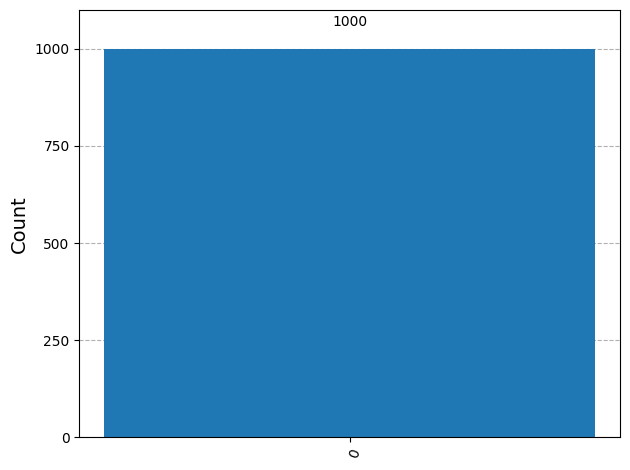

In [124]:
qc = your_circuit(secret_function())
result = AerSimulator().run(qc, shots=1000, memory=True).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

## 1b) Gain intuition for the circuits and the different gates

Now that we have a working implementation of Deutsch's algorithm, lets try to modify the circuit and see if it still gives the correct result. Answer the following questions as precisely as possible:

- What happens if a Hadamard gate is added or removed? Why?
- What happens if an X or Z gate is added or removed? Why?
- What happens if we add a SWAP gate?
- Does it matter if the previous changes happen before or after the query gate?
- Assuming we can only measure the other other qubit, is there a way to change the circuit to still obtain the correct result?
- If the circuit would be initialised in the Bell state $\vert \Phi^+ \rangle = \frac{1}{\sqrt{2}}\left(\vert 0 \rangle + \vert 1 \rangle \right)$ , how would you have to modify it to still obtain the correct result?

Bonus questions:
- Can you modify the `secret_function` such that you can try all four possible functions?
- Can you extend the circuit to the Deutsch-Josza algorithm for two-qubit functions?

**What happens if a Hadamard gate is added or removed? Why?**

In [136]:
# Let code the  circuit with Hadamard
def circuit_with_hadamards(function: QuantumCircuit, hadamards_before=True, hadamards_after=True):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    # Hadamard before
    if hadamards_before:
        qc.h(range(n))
    # Default gate for the circuit (which do not change)
    qc.x(n)
    qc.h(n)

    qc.barrier()
    # CNOT
    qc.compose(function, inplace=True)
    qc.barrier()
    # Hadamard after
    if hadamards_after:
        qc.h(range(n))

    qc.measure(range(n), range(n))
    return qc

Circuit with Hadamards before and after:


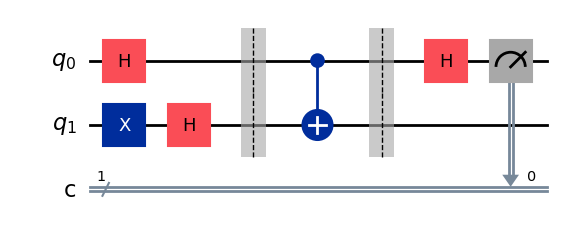


Circuit with Hadamards only before:


In [152]:
print("Circuit with Hadamards before and after:")
display(circuit_with_hadamards(secret_function()).draw(output='mpl'))
print("\nCircuit with Hadamards only before:")
# display(circuit_with_hadamards(secret_function(), hadamards_after=False).draw(output='mpl'))
# print("\nCircuit with Hadamards only after:")
# display(circuit_with_hadamards(secret_function(), hadamards_before=False).draw(output='mpl'))
# print("\nCircuit without Hadamards:")
# display(circuit_with_hadamards(secret_function(), hadamards_before=False, hadamards_after=False).draw(output='mpl'))

- **First Hadamard gate**: creates superposition → essential for testing both 0 and 1 in a single call.

- **Last Hadamard gate**: transforms phases into measurable amplitudes → essential for obtaining the correct result.

- **When we remove a Hadamard gate** → the circuit no longer works.This is  because superposition or phase-to-amplitude transformation is missing.

- **When we Add an unnecessary Hadamard gate** → may not change anything (H·H = I) or may distort the result if placed incorrectly.



**What happens if an X or Z gate is added or removed? Why?**

In [138]:
# Effect of X and Z gates
def circuit_with_xz_gates(function: QuantumCircuit, gate_type='x', before_query=True):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    # Default gate for the circuit (which do not change)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)
    #  our
    if before_query:
        if gate_type == 'x':
            qc.x(0)
        elif gate_type == 'z':
            qc.z(0)

    qc.barrier()
    # Our CNOT
    qc.compose(function, inplace=True)
    qc.barrier()

    if not before_query:
        if gate_type == 'x':
            qc.x(0)
        elif gate_type == 'z':
            qc.z(0)

    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


Circuit with X gate before query:


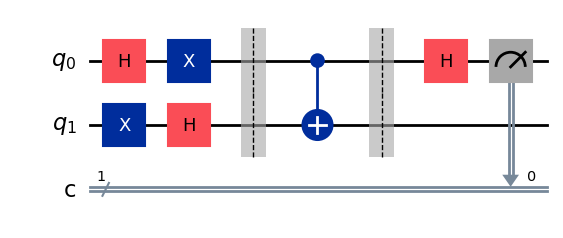

In [153]:
print("\nCircuit with X gate before query:")
display(circuit_with_xz_gates(secret_function(), gate_type='x', before_query=True).draw(output='mpl'))
# print("\nCircuit with X gate after query:")
# display(circuit_with_xz_gates(secret_function(), gate_type='x', before_query=False).draw(output='mpl'))
# print("\nCircuit with Z gate before query:")
# display(circuit_with_xz_gates(secret_function(), gate_type='z', before_query=True).draw(output='mpl'))
# print("\nCircuit with Z gate after query:")
# display(circuit_with_xz_gates(secret_function(), gate_type='z', before_query=False).draw(output='mpl'))

Adding or removing X or Z gates in the Deutsch algorithm can significantly alter the circuit's behavior and lead to incorrect results, depending on their placement.

- **X gate (NOT gate):** The X gate inverts the state of a qubit ($\vert 0 \rangle \leftrightarrow \vert 1 \rangle$). If placed before the oracle on the input qubit, it changes the input state queried by the function. If placed after the oracle and before the final Hadamard gate, it can disrupt the phase relationships necessary for the algorithm to function correctly.
- **Z gate (phase gate):** The Z gate applies a phase shift to the $\vert 1 \rangle$ state ($\vert 1 \rangle \rightarrow -\vert 1 \rangle$). If placed on the input qubit, it can modify the phase of the superposition state before or after the oracle, thus disrupting the interference pattern.

In the Deutsch algorithm, the initial state preparation and the final measurement step rely on specific phase relationships created by the Hadamard gates and the oracle. Arbitrarily adding or removing X or Z gates will generally break these relationships, preventing the algorithm from correctly distinguishing between constant and balanced functions.

**What happens if we add a SWAP gate?**

In [146]:
def circuit_with_swap(function: QuantumCircuit, before_query=True):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    # Default gate for the circuit (which do not change)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)

    if before_query:
        qc.swap(0, n)

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    if not before_query:
        qc.swap(0, n)

    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc



Circuit with SWAP gate before query:


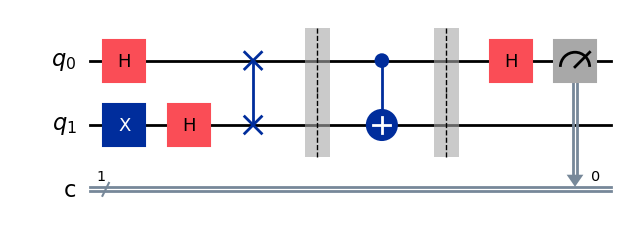


Circuit with SWAP gate after query:


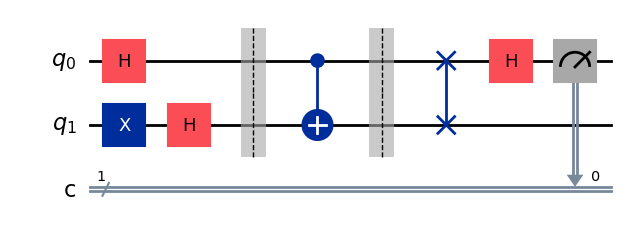

In [147]:
print("\nCircuit with SWAP gate before query:")
display(circuit_with_swap(secret_function(), before_query=True).draw(output='mpl'))
print("\nCircuit with SWAP gate after query:")
display(circuit_with_swap(secret_function(), before_query=False).draw(output='mpl'))

**Adding a SWAP gate exchanges the states of two qubits. In the context of Deutsch's algorithm:**

If the SWAP gate is placed before the oracle: the input qubit and the auxiliary qubit are swapped. The oracle then acts on the wrong qubits, which can lead to an incorrect result, as the function is applied to the wrong input.

If the SWAP gate is placed after the oracle but before the measurement: the qubits are swapped, and there is a risk of measuring the auxiliary qubit instead of the input qubit. Since Deutsch's algorithm requires measuring the input qubit after the final Hadamard gate, this can also lead to an incorrect or meaningless result.

**Is it important whether the preceding modifications occur before or after the query gate?**

Yes, the placement of gates before or after the query gate is crucial. The order of operations in a quantum circuit is critical. Gates placed before the query gate prepare the input state, while those placed after process the output of the query and prepare for measurement. Changing the order or removing gates will alter the quantum state at different stages and affect the final measurement result, potentially leading to an incorrect outcome.


Circuit measuring the other qubit:


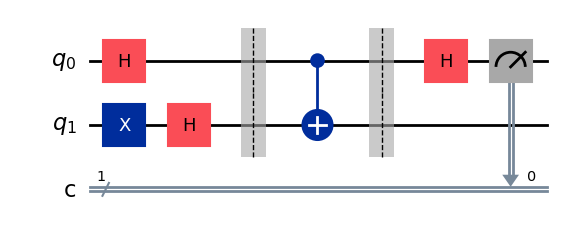


Result when measuring the other qubit:
['1']


'balanced'

In [150]:
# Measuring the other qubit
def circuit_measure_other_qubit(function: QuantumCircuit):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    # Default gate for the circuit (which do not change)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    qc.h(range(n))
    qc.measure(0, 0)

    return qc

print("\nCircuit measuring the other qubit:")
display(circuit_measure_other_qubit(secret_function()).draw(output='mpl'))
print("\nResult when measuring the other qubit:")
display(deutsch_algorithm(circuit_measure_other_qubit(secret_function())))



**Assuming we can only measure the other qubit, is it possible to modify the circuit to still obtain the correct result?**

In the standard Deutsch algorithm, directly measuring the auxiliary qubit does not yield the correct result regarding whether the function is constant or balanced. The algorithm is designed to encode this information into the state of the input qubit after the oracle and the final Hadamard gate, which is why we measure the input qubit.

Measuring the auxiliary qubit would give us the value of $f(x)$ for the input state $x$ that was in superposition, but this would not provide the necessary interference to distinguish constant functions from balanced functions.

**- If the circuit would be initialised in the Bell state $\vert \Phi^+ \rangle = \frac{1}{\sqrt{2}}\left(\vert 0 \rangle + \vert 1 \rangle \right)$ , how would you have to modify it to still obtain the correct result?**



Circuit initialized in Bell state:


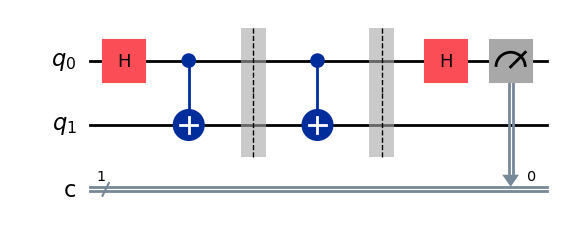


Result when initialized in Bell state:
['0']


'constant'

In [151]:
# Initializing in the Bell state
def circuit_bell_state_init(function: QuantumCircuit):
    n = function.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)

    # Initialize in |phi+> = 1/sqrt(2) (|00> + |11>) for n=1
    qc.h(0)
    qc.cx(0, 1)

    qc.barrier()
    qc.compose(function, inplace=True)
    qc.barrier()

    # Apply Hadamard to the first qubit
    qc.h(0)

    qc.measure(range(n), range(n))
    return qc

print("\nCircuit initialized in Bell state:")
display(circuit_bell_state_init(secret_function()).draw(output='mpl'))
print("\nResult when initialized in Bell state:")
display(deutsch_algorithm(circuit_bell_state_init(secret_function())))

**Bonus questions:**
- Can you modify the `secret_function` such that you can try all four possible functions?
- Can you extend the circuit to the Deutsch-Josza algorithm for two-qubit functions?

# 2. Grovers algorithm

In this question, we want to verify that Grovers algorithm indeed works as we have predicted in the last two lectures. We will follow the lecture and check all the claims that have been made - and in the end will be able to verify the quantum advantage of this algorithm!

In [140]:
# --- Imports & helpers ---
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import DiagonalGate
from qiskit.quantum_info import Operator, Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

## 2a) Problem setup, $Z_f$ and $Z_{OR}$

We want to create a function that is 0 on all bitstrings except for our specific goal-string which we call `marked`. Below, you can choose the number of bits and the marked bitstring.

In [154]:
# Set problem size and the marked string (you may change this)
n = 3
marked = "101"  # <- choose your marked bitstring; e.g., "101"
assert len(marked) == n, "Length of marked string must be equal to n."

def bitstr_to_index(s: str) -> int:
    """Maps a bitstring to its computational-basis index."""
    return int(s, 2)

N = 2**n
idx_star = bitstr_to_index(marked)
print(f"N={N}, marked={marked}, index={idx_star}")

N=8, marked=101, index=5


We now want to construct the phase query gate $Z_f$ for the function which is 0 on all bistrings except the marked bitstring. You can verify that the correct matrix representation for the $Z_f$-gate is diagonal with every diagonal entry equal to $1$, except for the entry corresponding to the marked element (given by index `idx_star` using lexicographical ordering).

In particular, check that $Z_f \vert x \rangle = (-1)^{f(x)} \vert x \rangle$ for all $x$.


In [155]:
# Z_f: +1 on all states except a single -1 at the marked index
diag_Zf = np.ones(N, dtype=complex)
diag_Zf[idx_star] = -1

We can construct $Z_{OR}$ using similar reasoning: all diagonal elements should be $-1$, except the element corresponding to $\vert 00...0\rangle$, which is the first.

In [156]:
# Z_or: +1 on |000...0> and -1 on all other basis states
diag_Zor = np.full(N, -1.0 + 0.0j)
diag_Zor[0] = 1.0

From this, we can now define the gates as circuit elements in Qiskit.

In [157]:
def Zf_gate(n: int, marked_index: int) -> DiagonalGate:
    diag = np.ones(2**n, dtype=complex)
    diag[marked_index] = -1
    return DiagonalGate(diag)

def Zor_gate(n: int) -> DiagonalGate:
    diag = np.full(2**n, -1.0 + 0.0j)
    diag[0] = 1.0
    return DiagonalGate(diag)

We now want to check that these gates are correct. Your intuition would be to simply apply the gates to a computational basis state $\vert x \rangle$ and check that the outcome is either $+\vert x \rangle$ or $-\vert x \rangle$ as appropriate.

But: these two states differ only by a global phase, therefore measurements cannot tell you which state you have! With this in mind, can you design a way to verify that the gates work correctly, only from measurement outcomes on well-chosen input states.

Verifying Zf_gate for marked state |101> (index 5):


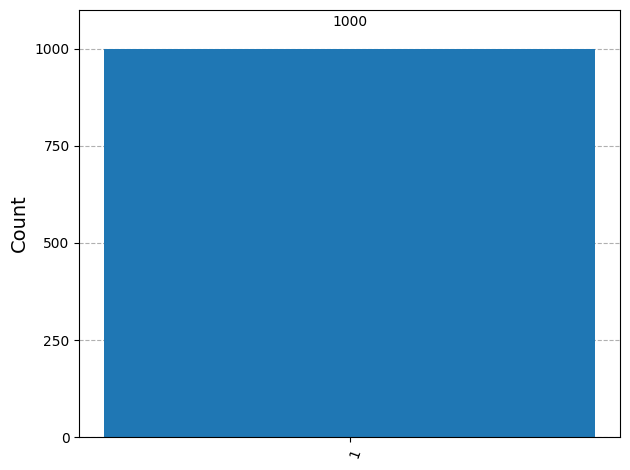

Expected outcome for Zf on marked state: '1' (indicating a -1 phase)

Verifying Zf_gate for non-marked state |0000000000> (index 0):


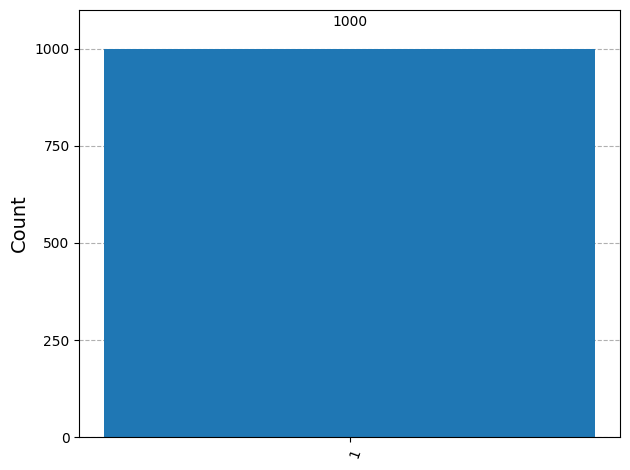

Expected outcome for Zf on non-marked state: '0' (indicating a +1 phase)


In [184]:
# Verify the gates using QuantumCircuit here

def verify_phase_gate(gate, n, input_state_index):
    """Verifies the phase applied by a diagonal gate to a specific input state."""
    qc = QuantumCircuit(n + 1, 1) # Add an auxiliary qubit for controlled operation

    # Prepare the input state |input_state_index>
    for i in range(n):
        if (input_state_index >> i) & 1:
            qc.x(i)

    # Prepare the auxiliary qubit in |-> state
    qc.x(n)
    qc.h(n)

    # Apply the controlled gate
    # If the target state (input_state_index) has a -1 phase,
    # the auxiliary qubit will flip from |-> to |+>.
    controlled_gate = gate.control(1)
    qc.append(controlled_gate, list(range(n)) + [n])

    # Apply Hadamard to the auxiliary qubit to make the phase observable
    qc.h(n)

    # Measure the auxiliary qubit
    qc.measure(n, 0)

    return qc

simulator = AerSimulator()

# Verify Zf_gate for the marked state
print(f"Verifying Zf_gate for marked state |{marked}> (index {idx_star}):")
qc_zf_marked = verify_phase_gate(Zf_gate(n, idx_star), n, idx_star)
tqc_zf_marked = transpile(qc_zf_marked, backend=simulator) # Transpile the circuit
result_zf_marked = simulator.run(tqc_zf_marked, shots=1000).result()
counts_zf_marked = result_zf_marked.get_counts()
display(plot_histogram(counts_zf_marked))
print("Expected outcome for Zf on marked state: '1' (indicating a -1 phase)")


# Verify Zf_gate for a non-marked state (e.g., index 0)
non_marked_index = 0 if idx_star != 0 else 1
print(f"\nVerifying Zf_gate for non-marked state |{bin(non_marked_index)[2:].zfill(n)}> (index {non_marked_index}):")
qc_zf_non_marked = verify_phase_gate(Zf_gate(n, idx_star), n, non_marked_index)
tqc_zf_non_marked = transpile(qc_zf_non_marked, backend=simulator) # Transpile the circuit
result_zf_non_marked = simulator.run(tqc_zf_non_marked, shots=1000).result()
counts_zf_non_marked = result_zf_non_marked.get_counts()
display(plot_histogram(counts_zf_non_marked))
print("Expected outcome for Zf on non-marked state: '0' (indicating a +1 phase)")

## 2b) Constructing the circuit

Now we have all ingredients to construct the full circuit. Complete the function `grover_operator`.

In [179]:
def grover_operator(n: int, marked_index: int) -> QuantumCircuit:
    qc = QuantumCircuit(n, name="G")
    # Z_f: +1 on all states except a single -1 at the marked index
    diag_Zf = np.ones(2**n, dtype=complex)
    diag_Zf[marked_index] = -1
    Zf = DiagonalGate(diag_Zf)
    qc.append(Zf, list(range(n)))

    qc.h(range(n))
    qc.x(range(n))
    qc.compose(Zor_gate(n), list(range(n)), inplace=True)
    qc.x(range(n))
    qc.h(range(n))

    return qc


def grover_circuit(n: int, marked_index: int, t: int) -> QuantumCircuit:
    qc = QuantumCircuit(n, n, name=f"Grover_t={t}")
    qc.h(range(n))
    G_instr = grover_operator(n, marked_index).to_instruction()
    for _ in range(t):
        qc.append(G_instr, list(range(n)))
    qc.measure(range(n), range(n))
    return qc

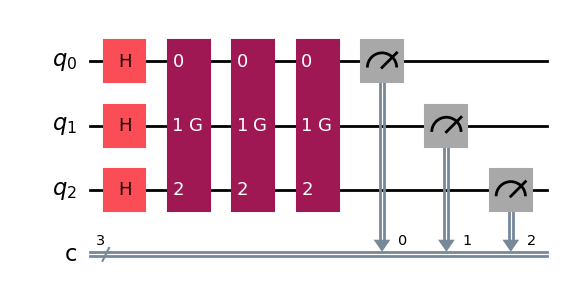

In [180]:
grover_circuit(n, idx_star, 3).draw("mpl")

## 2c) Circuit depth
How often should we apply $G$ to best separate the marked bitstring from the others?

Here we have to exploit the knowledge of how many marked bitstrings there are, in this case 1.

And now lets check if everything was correct: plot the histogram of measurement results for different numbers of implementations of the Grover operator and investigate whether our theoretically optimal $t$ is indeed the best.

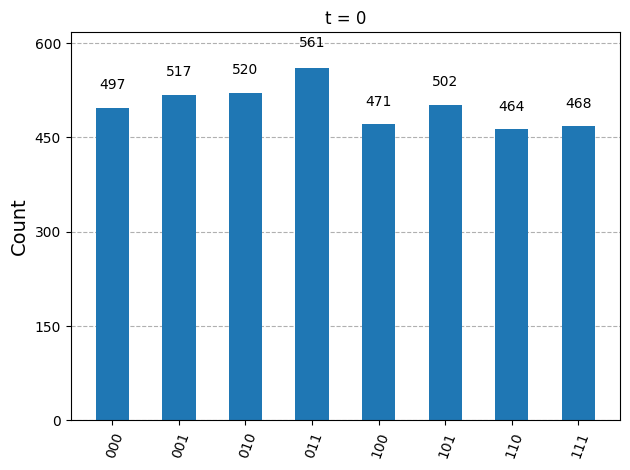

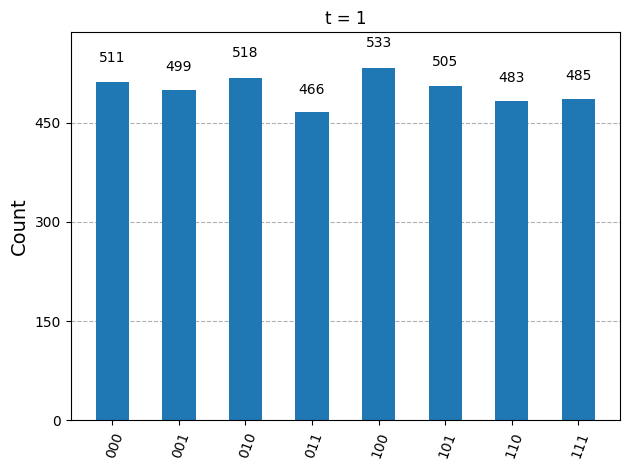

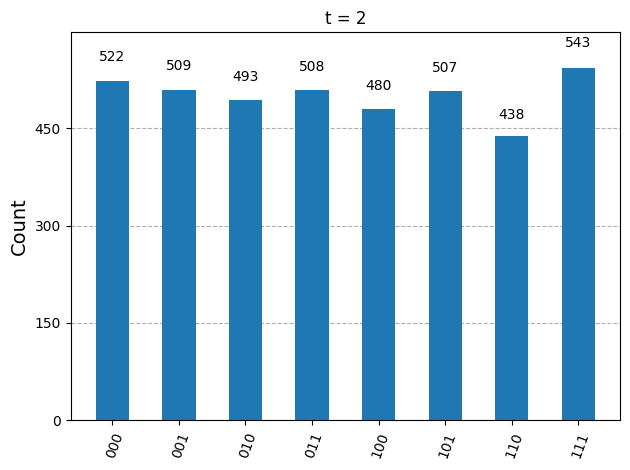

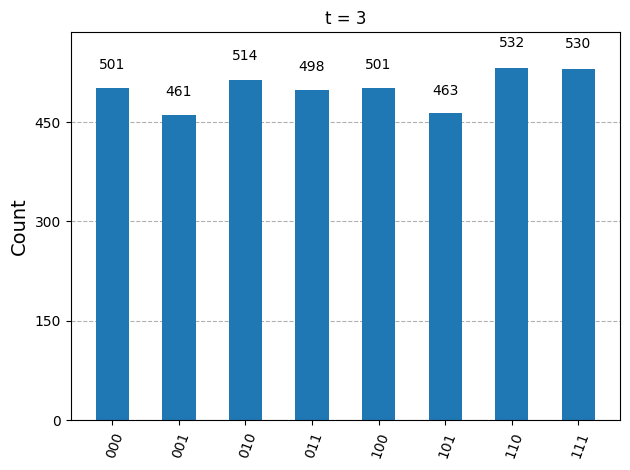

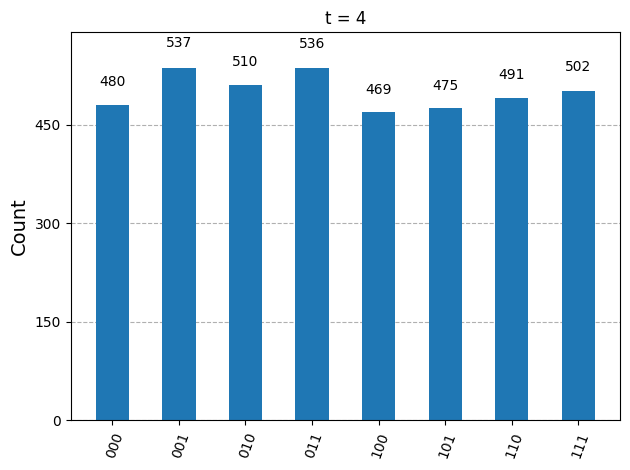

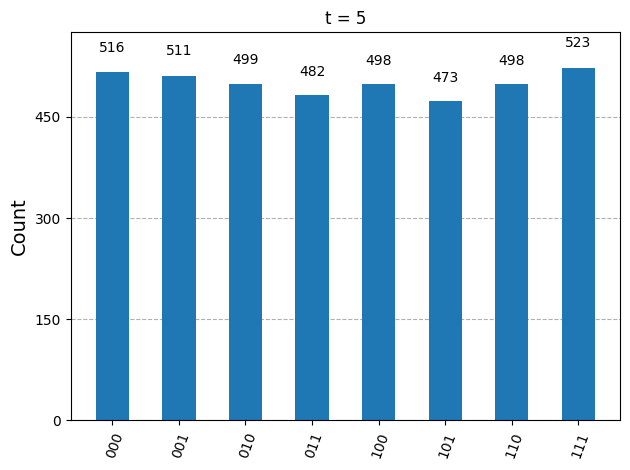

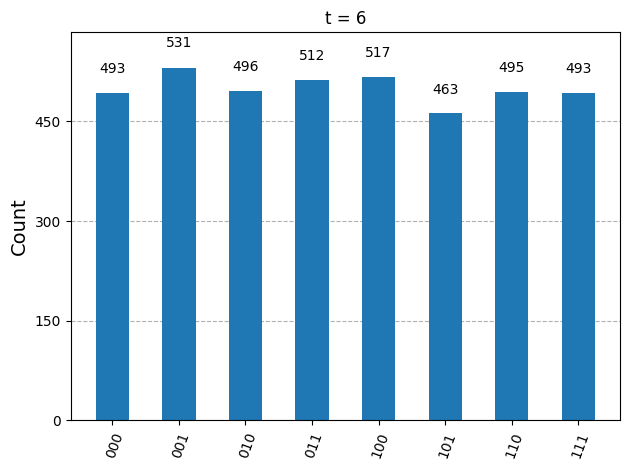

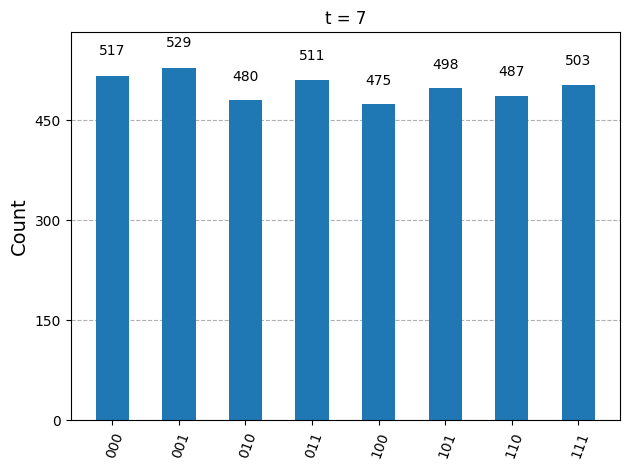

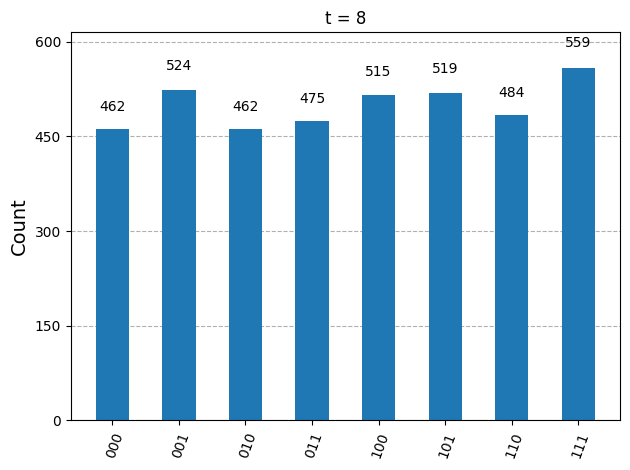

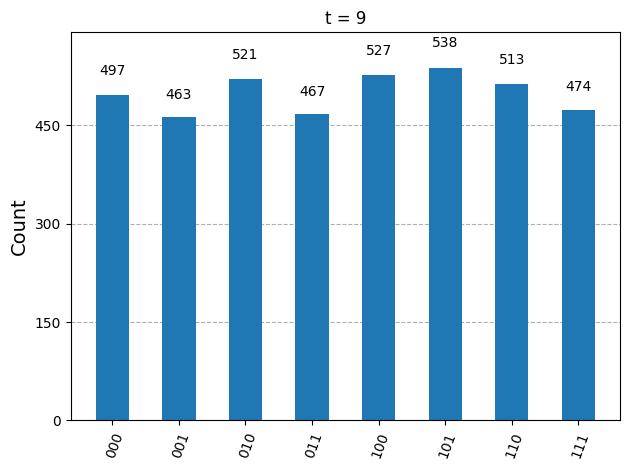

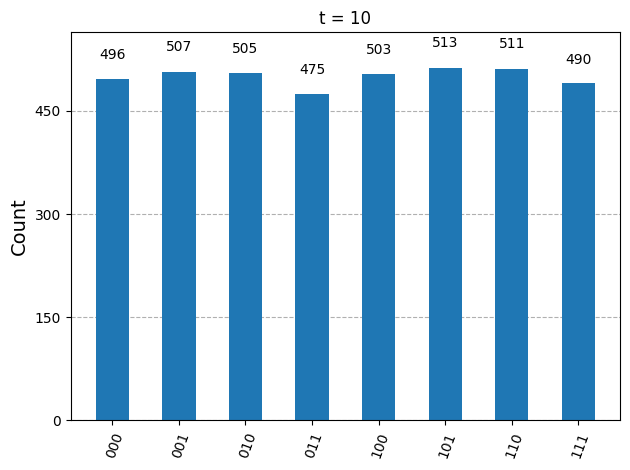

In [98]:
sim = AerSimulator()
x = 10
histograms = {}

for t in range(0, x+1):
    qc = grover_circuit(n, idx_star, t)
    tqc = transpile(qc, backend=sim)
    result = sim.run(tqc, shots=4000).result()
    counts = result.get_counts()
    histograms[t] = counts

    display(plot_histogram(counts, title=f"t = {t}"))


## 2d) Bonus - Query complexity

We have now seen that Grovers algorithm indeed works for $N=3$. In the lecture it was claimed that this algorithm scales $\mathcal{O}(\sqrt{N})$ - check this claim as far as your computing resources permit.

Testing Grover's algorithm scaling:

For n=3 (N=8), optimal iterations (t): 2
  Execution time: 0.001686 seconds

For n=4 (N=16), optimal iterations (t): 3
  Execution time: 0.002003 seconds

For n=5 (N=32), optimal iterations (t): 4
  Execution time: 0.002522 seconds

For n=6 (N=64), optimal iterations (t): 6
  Execution time: 0.003751 seconds

For n=7 (N=128), optimal iterations (t): 9
  Execution time: 0.006307 seconds

For n=8 (N=256), optimal iterations (t): 13
  Execution time: 0.010372 seconds

For n=9 (N=512), optimal iterations (t): 18
  Execution time: 0.018760 seconds

For n=10 (N=1024), optimal iterations (t): 25
  Execution time: 0.034858 seconds


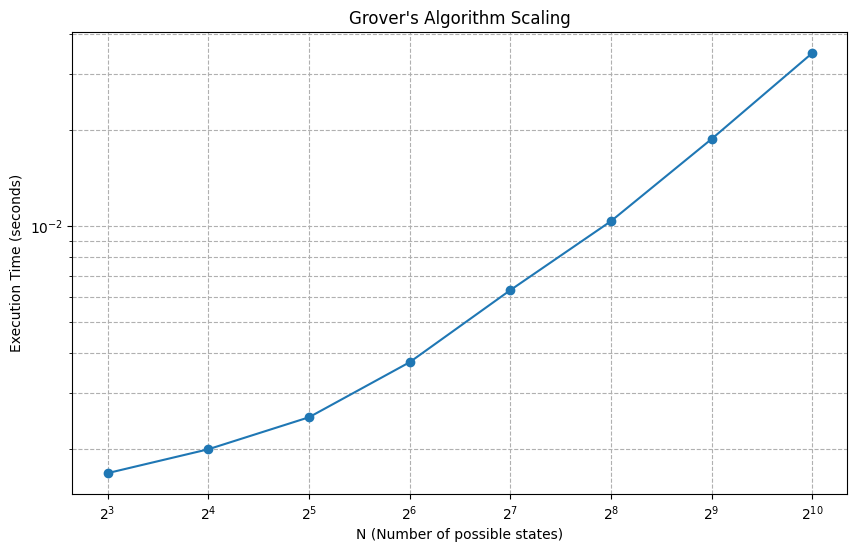

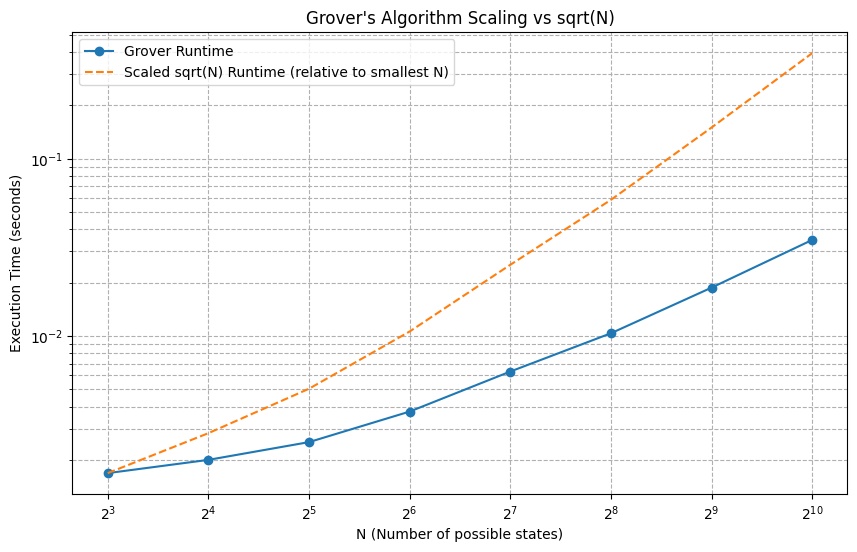

In [181]:
import time
import math

# Check the O(sqrt(N)) scaling claim

def find_optimal_t(N):
    """Calculates the optimal number of Grover iterations."""
    # For a single marked item, the optimal number of iterations is round(pi/4 * sqrt(N))
    return round(math.pi / 4 * math.sqrt(N))

simulator = AerSimulator()
n_values = range(3, 11)  # Choose a range of n values to test (e.g., from 3 to 10)
runtimes = []
N_values = []

print("Testing Grover's algorithm scaling:")
for n in n_values:
    N = 2**n
    N_values.append(N)
    marked_index = 0 # Choose a marked index (doesn't affect scaling)
    optimal_t = find_optimal_t(N)
    print(f"\nFor n={n} (N={N}), optimal iterations (t): {optimal_t}")

    # Build and transpile the circuit
    qc = grover_circuit(n, marked_index, optimal_t)
    # Transpile the circuit for the simulator backend
    tqc = transpile(qc, backend=simulator)

    # Measure the execution time
    start_time = time.time()
    result = simulator.run(tqc, shots=1).result() # Run with 1 shot for timing
    end_time = time.time()
    runtime = end_time - start_time
    runtimes.append(runtime)
    print(f"  Execution time: {runtime:.6f} seconds")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(N_values, runtimes, marker='o', linestyle='-')
plt.xlabel('N (Number of possible states)')
plt.ylabel('Execution Time (seconds)')
plt.title('Grover\'s Algorithm Scaling')
plt.xscale('log', base=2)
plt.yscale('log')
plt.grid(True, which="both", linestyle='--')
plt.show()

# Optional: Compare with sqrt(N) scaling
sqrt_N_values = [math.sqrt(N) for N in N_values]
plt.figure(figsize=(10, 6))
plt.plot(N_values, runtimes, marker='o', linestyle='-', label='Grover Runtime')
plt.plot(N_values, [r * (sqrt_N_values[i] / sqrt_N_values[0]) for i, r in enumerate(runtimes)], linestyle='--', label='Scaled sqrt(N) Runtime (relative to smallest N)')
plt.xlabel('N (Number of possible states)')
plt.ylabel('Execution Time (seconds)')
plt.title('Grover\'s Algorithm Scaling vs sqrt(N)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.grid(True, which="both", linestyle='--')
plt.legend()
plt.show()

## 2e) Bonus - $Z_f$ and $Z_{OR}$

We have seen $Z_f$ and $Z_{OR}$ in the lecture and now constructed them easily using its matrix representation. In reality though, this way of constructing a gate is not possible, we always need to construct more complicated cicuits from the elementary gates. Using Lesson 6 from [the book](https://arxiv.org/pdf/2507.11536), can you express $Z_f$ and $Z_{OR}$ using elementary gates?

In [185]:
def Zf_elementary(n, marked_index):
    qc = QuantumCircuit(n, name="Zf_elementary")
    marked_bin = bin(marked_index)[2:].zfill(n)

    # Apply X to qubits where marked bit is 0
    for qubit, bit in enumerate(marked_bin):
        if bit == '0':
            qc.x(qubit)

    # Apply multi-controlled Z (for n qubits, use H + multi-controlled X trick)
    if n == 1:
        qc.z(0)
    else:
        qc.h(n-1)
        qc.mcx(list(range(n-1)), n-1)  # multi-controlled X
        qc.h(n-1)

    # Undo the X gates
    for qubit, bit in enumerate(marked_bin):
        if bit == '0':
            qc.x(qubit)

    return qc


In [186]:
def ZOR_elementary(n):
    qc = QuantumCircuit(n, name="ZOR_elementary")

    # Apply X to all qubits to turn |0...0> into |1...1>
    for q in range(n):
        qc.x(q)

    # Multi-controlled Z on all qubits
    if n == 1:
        qc.z(0)
    else:
        qc.h(n-1)
        qc.mcx(list(range(n-1)), n-1)
        qc.h(n-1)

    # Undo X gates
    for q in range(n):
        qc.x(q)

    return qc


Zf circuit:


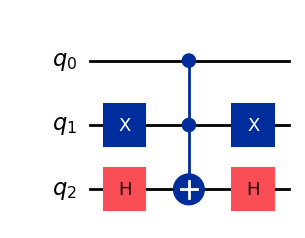

ZOR circuit:


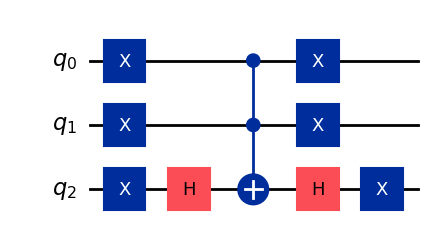

In [187]:
# --- Visualize circuits ---
n = 3
marked_index = 5

qc_zf = Zf_elementary(n, marked_index)
qc_zor = ZOR_elementary(n)

# Display the circuits
print("Zf circuit:")
display(qc_zf.draw('mpl'))

print("ZOR circuit:")
display(qc_zor.draw('mpl'))
